In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/flights.csv')
print(df.head())

# 1. Combine year and month into an ordered datetime index
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df['month_num'] = df['month'].map(month_map)
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month_num'].astype(str) + '-01')
df = df.sort_values('date').reset_index(drop=True)
df.head()

   year     month  passengers
0  1949   January         112
1  1949  February         118
2  1949     March         132
3  1949     April         129
4  1949       May         121


,year,month,passengers,month_num,date
0,1949,January,112,1,1949-01-01
1,1949,February,118,2,1949-02-01
2,1949,March,132,3,1949-03-01
3,1949,April,129,4,1949-04-01
4,1949,May,121,5,1949-05-01


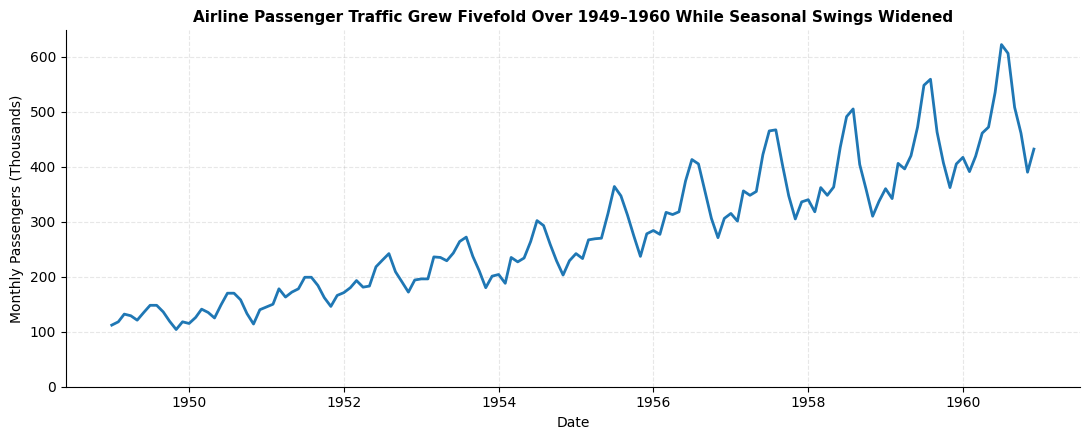

In [2]:
plt.figure(figsize=(11, 4.5))
plt.plot(df['date'], df['passengers'], color='#1f77b4', lw=2)

plt.title("Airline Passenger Traffic Grew Fivefold Over 1949–1960 While Seasonal Swings Widened", 
          fontsize=11, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Monthly Passengers (Thousands)")
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Observation for Chart 1
The continuous time series reveals two distinct dynamics happening simultaneously:
1. **A strong secular upward trend:** Passenger volume grew consistently from ~100k in 1949 to over 600k by 1960.
2. **A regular within-year oscillation:** Recurring seasonal spikes in summer and troughs in winter that expand in absolute amplitude each year.

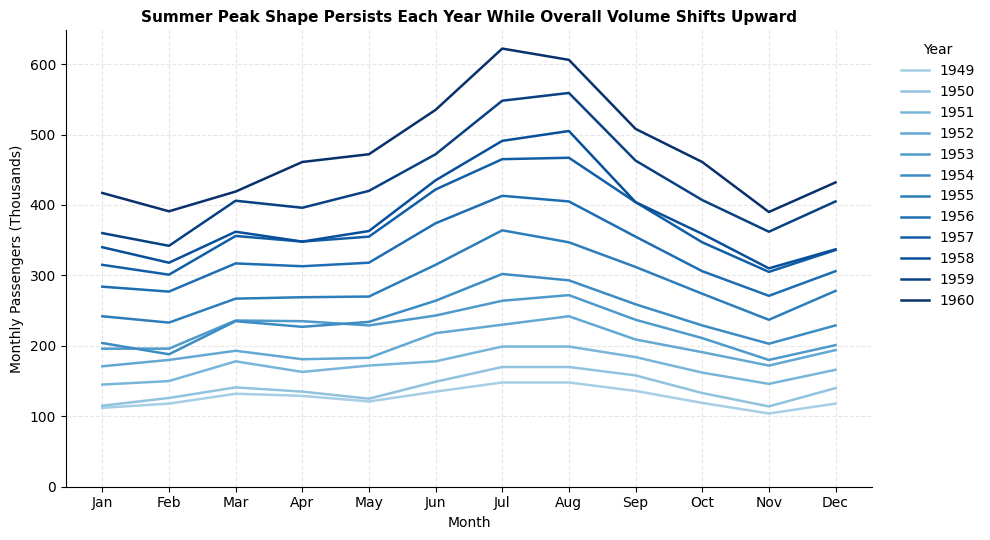

In [3]:
month_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
years = sorted(df['year'].unique())

plt.figure(figsize=(10, 5.5))
# Gradient blue palette to distinguish older from newer years naturally
colors = plt.cm.Blues(np.linspace(0.35, 1.0, len(years)))

for yr, col in zip(years, colors):
    ydata = df[df['year'] == yr]
    plt.plot(ydata['month_num'], ydata['passengers'], label=str(yr), color=col, lw=1.8)

plt.title("Summer Peak Shape Persists Each Year While Overall Volume Shifts Upward", 
          fontsize=11, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Monthly Passengers (Thousands)")
plt.xticks(range(1, 13), month_abbr)
plt.ylim(bottom=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, title='Year')
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Justification for Chart 2
By stacking all 12 years across the shared January–December axis, we isolate the calendar cycle from the secular multi-year drift. This proves the seasonal curve has an invariant structural geometry: a dip in February, a surge starting in May, a dual July–August peak, and a secondary minor bump in December.

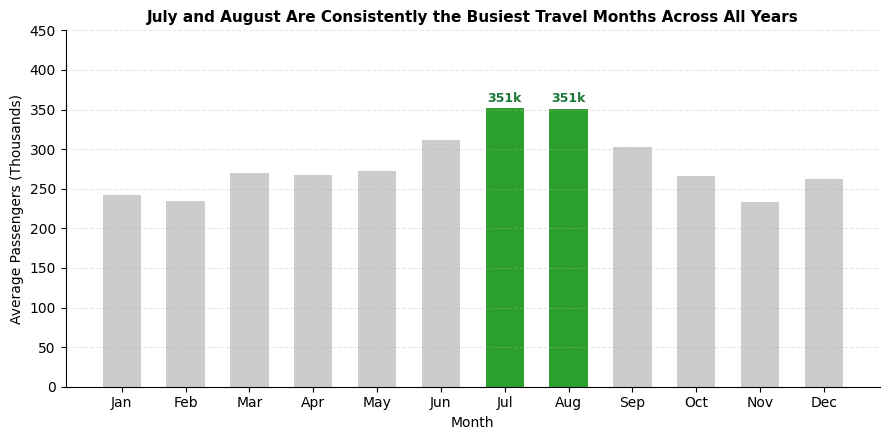

In [4]:
avg_by_month = df.groupby('month_num')['passengers'].mean()
month_labels = [month_abbr[i - 1] for i in avg_by_month.index]

plt.figure(figsize=(9, 4.5))
# Use purposeful color: green highlight for the peak months, muted grey for the rest
bar_colors = ['#2ca02c' if m in [7, 8] else '#cccccc' for m in avg_by_month.index]

bars = plt.bar(month_labels, avg_by_month.values, color=bar_colors, edgecolor='none', width=0.6)
plt.title("July and August Are Consistently the Busiest Travel Months Across All Years", 
          fontsize=11, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average Passengers (Thousands)")
plt.ylim(bottom=0, top=450)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)

# Direct data callouts for peak months
for b, m in zip(bars, avg_by_month.index):
    h = b.get_height()
    if m in [7, 8]:
        plt.text(b.get_x() + b.get_width() / 2, h + 8, f"{int(h)}k", ha='center', 
                 fontweight='bold', fontsize=9, color='#1b7837')

plt.tight_layout()
plt.show()

### 4. Which Chart Belongs in an Executive Report?
**Selected Chart:** **Chart 3 (Average Volume by Month)**.
- **Why it belongs:** An executive operations report needs an immediate, clutter-free answer to capacity planning bottlenecks. Chart 3 isolates the peak demand period (July and August) at a glance with zero cognitive overhead.
- **Why the other two do not belong in the same report:** 
  - Chart 1 is a macro historical trend chart that does not let an operations manager quickly read exact month-over-month resource requirements.
  - Chart 2 is an exploratory diagnostic chart whose 12 overlapping lines create visual noise for a decision-maker who simply needs the high-level demand pattern.

---

### Question: Is the growing swing caused by growing seasonality or airline growth?
**Answer:** The seasonality is **multiplicative**, not additive. The seasonal swings scale proportionally with the baseline volume of passengers.
- To prove this, we can plot **$\log(\text{passengers})$ over time** or calculate the **percentage seasonal index** (monthly volume divided by that year's 12-month moving average).
- On a log scale, the peak-to-trough vertical distance remains constant across all 12 years. This demonstrates that the airline's customer seasonality percentage stayed stable (~40% summer increase); the absolute swings grew larger simply because the customer base grew fivefold.